In [ ]:
!df -h /content
!du -h -d 2 /content | sort -h | tail -n 20

Filesystem      Size  Used Avail Use% Mounted on
overlay         226G   19G  207G   9% /
4.0K	/content/drive/.shortcut-targets-by-id
8.0K	/content/.config/configurations
12K	/content/drive/.Trash-0
92K	/content/.config/logs
148K	/content/.config
1.3M	/content/drive/.Encrypted
55M	/content/sample_data
11G	/content
11G	/content/drive
11G	/content/drive/MyDrive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# اول PyTorch 2.6 با CUDA 12.6 و ماژول‌های وابسته
!python -m pip install --upgrade --extra-index-url https://download.pytorch.org/whl/cu126 \
  torch==2.6.0+cu126 torchvision==0.21.0+cu126 torchaudio==2.6.0+cu126

# بعد MONAI پایدار و بقیه ابزارها
#!python -m pip install monai==1.5.0 nibabel pydicom tqdm scikit-image
!python -m pip install monai nibabel pydicom tqdm scikit-image

!pip install --upgrade monai


Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 382.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 410.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 399.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 158.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 157.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 184.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 324.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 262.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 224.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 204.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 194.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!apt -y install unrar
!pip -q install rarfile
!pip install importnb

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 100 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.8 MB/s eta 0:00:00


In [ ]:

# Gemini Ultra-SOTA Hyperparameters for BraTS2021
from dataclasses import dataclass
from typing import Tuple, List, Optional
import os
import torch
import torch.nn.functional as F
import numpy as np
from dataclasses import dataclass, field

@dataclass
class CFG:
    # =========================================================
    # 1. تنظیمات اصلی
    # =========================================================
    root_path: str = "/content/drive/MyDrive/Colab Notebooks/testi"
    save_dir: str  = "/content/drive/MyDrive/Colab Notebooks/testi/final_train_A100_160_SOTA_Lookahead_v2"
    seed: int = 42

    do_viz: bool = False
    do_plot: bool = True
    log_step_freq: int = 10

    deep_supervision: bool = True
    ds_weights: List[float] = field(default_factory=lambda: [0.5, 0.25])

    # =========================================================
    # 2. مسیرها و دیتالودر (بهینه‌سازی برای سرعت بالا)
    # =========================================================
    dataset_path: str = "/content/data/BraTS"

    cache_backend: str = "disk"
    # با ۸۰ گیگ VRAM و رم بالای سیستم در A100، بخشی از دیتا را کش می‌کنیم
    cache_rate: float = 0.8
    #cache_rate: float = 0.8

    cache_dir: str = "/content/cache_pre"

    kfold: int = 5
    fold: int = 0

    # ✅ تغییر استراتژی: افزایش Batch Size واقعی به جای Accumulation بیش از حد
    # در A100، بچ‌سایز 4 برای رزولوشن 160 به راحتی جا می‌شود و سرعت را 2 برابر می‌کند.
    batch_size: int = 1
    num_workers: int = 10          # افزایش برای تغذیه سریع GPU
    accum_iter: int = 4          # بچ‌سایز موثر همچنان 16 (4 * 4) باقی می‌ماند

    pin_memory: bool = True
    prefetch_factor: int = 2      # افزایش برای لود پیش‌دستانه دیتا

    val_sample_limit: int = 100   # اضافه کنید: فقط ۴۰ مورد از ۱۲۵۰ تا برای ولیدیشن سریع
    # =========================================================
    # 3. تنظیمات سایز و نمونه‌برداری
    # =========================================================
    patch_size: Tuple[int,int,int] = (160, 160, 160)
    roi_size: Tuple[int,int,int]   = (160, 160, 160)

    num_samples: int = 3          # برداشت 2 پچ از هر حجم؛ تنوع داده را در هر بچ بالا می‌برد
    min_frac: float = 0.3
    pos_ratio: float = 0.7
    pos_dilate_kernel: int = 3

    # =========================================================
    # 4. معماری مدل
    # =========================================================
    num_classes: int = 4
    base_ch: int = 64
    num_heads: int = 8
    deep_supervision: bool = True

    # دریفت دراپ‌اوت برای جلوگیری از اوورفیت روی 1250 تصویر
    dropout: float = 0.20         # کمی افزایش برای دیتای بزرگ
    attn_dropout: float = 0.15
    proj_dropout: float = 0.15
    ffn_dropout: float = 0.20
    dec_dropout: float = 0.25

    #ds_weights: Optional[List[float]] = None

    # =========================================================
    # 5. تنظیمات آموزش (Advanced AdamW)
    # =========================================================
    epochs: int = 150
    warmup_epochs: int = 10
    lr: float = 1e-5
    #lr: float = 1e-3              # ریت 1e-3 گاهی باعث انفجار گرادیان می‌شود؛ 8e-4 با بچ 16 ایمن‌تر است
    weight_decay: float = 3e-5    # مقدار استاندارد SOTA
    clip_grad_norm: float = 1.0

    use_amp: bool = True

    lambda_dice: float = 1.0
    lambda_ce: float = 1.0
    ds_weight_start: float = 0.5

    # =========================================================
    # 6. تنظیمات پیشرفته و اینفرنس (SOTA Precision)
    # =========================================================
    ema_alpha: float = 0.995      # افزایش پایداری Teacher در دیتای زیاد
    kd_temp: float = 3.0
    kd_max_weight: float = 0.5

    sw_batch_size: int = 2        # ولیدیشن سریع‌تر روی A100
    sw_roi_size: Tuple[int,int,int] = (160, 160, 160)
    sw_overlap: float = 0.7      # ✅ افزایش به 0.7 برای دقت حداکثری در مرزهای تومور
    hd_every: int = 3

    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    channels_last: bool = True

# =========================================================
# مقداردهی نهایی
# =========================================================
cfg = CFG()
#if cfg.deep_supervision and (cfg.ds_weights is None):
#    cfg.ds_weights = [0.50, 0.25]

os.makedirs(cfg.save_dir, exist_ok=True)
print(f"🚀 Gemini SOTA Config Loaded for A100!")

🚀 Gemini SOTA Config Loaded for A100!


In [ ]:
# Download dataset from kaggle

In [ ]:

#!kaggle datasets list -s brats-2021

In [ ]:


from google.colab import drive
import os

# ۱. اتصال به درایو
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# ۲. تنظیمات کگل
!mkdir -p ~/.kaggle
!cp "/content/drive/MyDrive/kaggle.json" ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# ۳. دانلود با مدیریت خطا
# استفاده از --quiet برای جلوگیری از پر شدن لاگ و سرعت بیشتر
print("🚀 Downloading dataset (this may take a while)...")
!kaggle datasets download -d dschettler8845/brats-2021-task1 -p /content/data/BraTS --quiet

# ۴. چک کردن وجود فایل قبل از آنزیپ
zip_path = "/content/data/BraTS/brats-2021-task1.zip"
if os.path.exists(zip_path):
    print('✅ Dataset downloaded successfully. Unzipping...')
    !unzip -q {zip_path} -d /content/data/BraTS
    # حذف فایل زیپ برای آزاد کردن فضا بعد از استخراج
    # !rm {zip_path}
    print('✨ All done!')
else:
    print('❌ Error: The zip file was not found. Check your Kaggle connection or disk space.')


🚀 Downloading dataset (this may take a while)...
Dataset URL: https://www.kaggle.com/datasets/dschettler8845/brats-2021-task1
License(s): copyright-authors
✅ Dataset downloaded successfully. Unzipping...
✨ All done!


In [ ]:
# importing Data Processing

In [ ]:


def setup_data_pipeline(cfg,
    *,
    root,
    notebook="preprocess_pipeline.ipynb",
    zip_path,
    extract_to,
    train_cache,
    val_cache,
    force_reextract=False,):

  path_to_nb = os.path.join(root, notebook)

  # اجرای نوت‌بوک؛ تمام توابع داخل آن حالا در دسترس هستند
  %run "$path_to_nb"


  dataset_root = prepare_dataset_from_archive(
        cfg,
        archive_path=zip_path,
        extract_dir=extract_to,
        ensure_cache_dirs=(train_cache, val_cache),
        force_reextract=force_reextract,
  )
  print("[dataset_root]", dataset_root)

  print('data is extracted ')

  cfg.dataset_path = dataset_root

  train_loader, val_loader = build_loaders(cfg, cfg.dataset_path )

  b = next(iter(train_loader))

  print("image:", b["image"].dtype, tuple(b["image"].shape))  # (N,4,128,128,128)
  print("label:", b["label"].dtype, tuple(b["label"].shape))  # (N,128,128,128)
  print(f"train_loader size = {len(train_loader)}")
  print(f"val_loader size   = {len(val_loader)}")


  return  dataset_root, train_loader, val_loader, b


In [ ]:

import torch
import torch.nn.functional as F
import shutil

cfg = CFG()

device = torch.device(cfg.device if getattr(cfg, "device", "auto") != "auto"
                          else ("cuda" if torch.cuda.is_available() else "cpu"))

ZIP_PATH    = "/content/data/BraTS/BraTS2021_Training_Data.tar"
EXTRACT_TO  = "/content/data/BraTS/dataset"
train_cache = "/content/cache_pre_train"
val_cache   = "/content/cache_pre_val"

# Clear existing cache directories to prevent I/O errors
if os.path.exists(train_cache): shutil.rmtree(train_cache)
if os.path.exists(val_cache): shutil.rmtree(val_cache)

dataset_root, train_loader, val_loader, batch = setup_data_pipeline(
    cfg,
    root=cfg.root_path,
    notebook="preprocess_pipeline.ipynb",
    zip_path=ZIP_PATH,
    extract_to=EXTRACT_TO,
    train_cache=train_cache,
    val_cache=val_cache,
    force_reextract=False, # Force re-extraction and cache regeneration
)


cfg.dataset_path = dataset_root   # مثلا "/content/data/BraTS/dataset"

print("dataset_root:", dataset_root)

print('**********     Data is processed       **********')


[dataset] extracting: /content/data/BraTS/BraTS2021_Training_Data.tar -> /content/data/BraTS/dataset


/tmp/ipykernel_3563/2121634530.py:37: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_dir)


Done.
[dataset_root] /content/data/BraTS/dataset
data is extracted 
📂 Loading Dataset from: /content/data/BraTS/dataset
[train] cases=1000
[val] cases=251
📊 [Stats] Train: 1000 | Val: 251
⚙️ Building Transforms...
🚀 Initializing Pipeline...
💾 [Cache] Using Disk Cache at: /content/cache_pre
✅ All Loaders Ready!


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


image: torch.float32 (3, 4, 160, 160, 160)
label: torch.int64 (3, 160, 160, 160)
train_loader size = 1000
val_loader size   = 251
dataset_root: /content/data/BraTS/dataset
**********     Data is processed       **********


In [ ]:
'''
import torch
import torch.nn.functional as F
import shutil

cfg = CFG()

device = torch.device(cfg.device if getattr(cfg, "device", "auto") != "auto"
                          else ("cuda" if torch.cuda.is_available() else "cpu"))

ZIP_PATH    = "/content/drive/MyDrive/brats2021_5.zip"
EXTRACT_TO  = "/content/data/BraTS/dataset"
train_cache = "/content/cache_pre_train"
val_cache   = "/content/cache_pre_val"

# Clear existing cache directories to prevent I/O errors
if os.path.exists(train_cache): shutil.rmtree(train_cache)
if os.path.exists(val_cache): shutil.rmtree(val_cache)

dataset_root, train_loader, val_loader, batch = setup_data_pipeline(
    cfg,
    root=cfg.root_path,
    notebook="preprocess_pipeline.ipynb",
    zip_path=ZIP_PATH,
    extract_to=EXTRACT_TO,
    train_cache=train_cache,
    val_cache=val_cache,
    force_reextract=False, # Force re-extraction and cache regeneration
)


cfg.dataset_path = dataset_root   # مثلا "/content/data/BraTS/dataset"

print("dataset_root:", dataset_root)

print('**********     Data is processed       **********')
'''

'\nimport torch\nimport torch.nn.functional as F\nimport shutil\n\ncfg = CFG()\n\ndevice = torch.device(cfg.device if getattr(cfg, "device", "auto") != "auto"\n                          else ("cuda" if torch.cuda.is_available() else "cpu"))\n\nZIP_PATH    = "/content/drive/MyDrive/brats2021_5.zip"\nEXTRACT_TO  = "/content/data/BraTS/dataset"\ntrain_cache = "/content/cache_pre_train"\nval_cache   = "/content/cache_pre_val"\n\n# Clear existing cache directories to prevent I/O errors\nif os.path.exists(train_cache): shutil.rmtree(train_cache)\nif os.path.exists(val_cache): shutil.rmtree(val_cache)\n\ndataset_root, train_loader, val_loader, batch = setup_data_pipeline(\n    cfg,\n    root=cfg.root_path,\n    notebook="preprocess_pipeline.ipynb",\n    zip_path=ZIP_PATH,\n    extract_to=EXTRACT_TO,\n    train_cache=train_cache,\n    val_cache=val_cache,\n    force_reextract=False, # Force re-extraction and cache regeneration\n)\n\n\ncfg.dataset_path = dataset_root   # مثلا "/content/data/Bra

In [ ]:
# importing Axial Attention Model

In [ ]:

# ===== simple_model_loader.py =====
from importnb import Notebook
import importlib, inspect, sys, os
from pathlib import Path

def build_model(
    cfg,
    module: str,                 # نام فایل نوت‌بوک بدون پسوند یا با ".ipynb" مثل: "MultiSeg_Model2" یا "MultiSeg_Model2.ipynb"
    class_name: str,             # نام کلاس داخل نوت‌بوک
    root: str | None = None,     # پوشه‌ی نوت‌بوک‌ها؛ پیش‌فرض از cfg.root_path
    fresh: bool = True,          # هر بار از نو import شود
    **extra_kwargs               # هرچی دستی بدی، اگر در signature بود ست می‌شود
):
    # 1) مسیر
    root = root or getattr(cfg, "model_py_path", getattr(cfg, "root_path", "."))
    root = os.path.abspath(root)
    if root not in sys.path:
        sys.path.append(root)

    # 2) نام ماژول (بدون .ipynb)
    module = Path(module).stem  # "x.ipynb" -> "x"

    # 3) تازه‌سازی
    if fresh and module in sys.modules:
        del sys.modules[module]

    # 4) import نوت‌بوک مثل ماژول
    with Notebook():
        mod = importlib.import_module(module)

    if not hasattr(mod, class_name):
        raise AttributeError(f"کلاس '{class_name}' داخل '{module}.ipynb' پیدا نشد.")

    Model = getattr(mod, class_name)

    # 5) ساخت kwargs خیلی ساده و خودکار از cfg
    sig_params = inspect.signature(Model).parameters
    pick = {}

    def get_any(*names, default=None):
        for n in names:
            if hasattr(cfg, n):
                return getattr(cfg, n)
        return default

    # نگاشت رایج + پارامترهای جدید dropout
    candidates = {
        # عمومی
        "in_channels":       get_any("in_channels", "in_ch", default=None),
        "num_classes":       get_any("num_classes", "out_ch", default=None),
        "base_ch":           get_any("base_ch", default=None),
        "num_heads":         get_any("num_heads", "heads", default=None),
        "up_method":         get_any("up_method", default=None),
        "deep_supervision":  get_any("deep_supervision", default=None),
        "img_size":          get_any("imgshape", "patch_size", default=None),
        "patch_size":        get_any("patch_size", default=None),

        # مخصوص مدل تو (اگر در امضای کلاس وجود داشته باشند پاس می‌شوند)
        "use_gating":        get_any("use_gating", default=None),
        "bottleneck_heads":  get_any("bottleneck_heads", default=None),
        "max_len":           get_any("max_len", default=None),
        "negative_slope":    get_any("negative_slope", default=None),
        "tcfc_depthwise":    get_any("tcfc_depthwise", default=None),
        "norm_type":         get_any("norm_type", default=None),

        # --- پارامترهای dropout (جدید) ---
        "dropout":           get_any("dropout", default=None),
        "attn_dropout":      get_any("attn_dropout", default=None),
        "proj_dropout":      get_any("proj_dropout", default=None),
        "ffn_dropout":       get_any("ffn_dropout", default=None),
        "dec_dropout":       get_any("dec_dropout", default=None),
    }

    # هرچی در امضای مدل هست و مقدارش None نیست را بردار
    for k, v in candidates.items():
        if k in sig_params and v is not None:
            pick[k] = v

    # هرچی دستی دادی (extra_kwargs) اگر در امضا باشد، override کند
    for k, v in extra_kwargs.items():
        if k in sig_params:
            pick[k] = v

    # 6) بساز و تمام
    model = Model(**pick)
    print(f"[model] {module}.{class_name} kwargs={pick}")
    return model


In [ ]:
# فرض: cfg.root_path = مسیر پوشه‌ی نوت‌بوک‌ها
#from simple_model_loader import build_model

model1 = build_model(
    cfg,
    module="MultiSeg_Model2.ipynb",
    class_name="MultiModalSegNet",
    root=cfg.root_path,   # یا نذار، خودش از cfg برمی‌داره
    fresh=True            # هر بار تغییرات نوت‌بوک اعمال شود
).to(cfg.device)


[model] MultiSeg_Model2.MultiModalSegNet kwargs={'num_classes': 4, 'base_ch': 64, 'num_heads': 8, 'deep_supervision': True, 'dropout': 0.2, 'attn_dropout': 0.15, 'proj_dropout': 0.15, 'ffn_dropout': 0.2, 'dec_dropout': 0.25}


In [ ]:
#test

In [ ]:
'''
b = next(iter(train_loader))
print("train_loader has kd_mask:", "kd_mask" in b)
print("image:", tuple(b["image"].shape), b["image"].dtype)  # (bs*num_samples, 4, 128, 128, 128), float32
print("label:", tuple(b["label"].shape), b["label"].dtype)  # (bs*num_samples, 128, 128, 128), int64

v = next(iter(val_loader))
print("val_loader has kd_mask:", "kd_mask" in v)
print("image:", tuple(v["image"].shape), v["image"].dtype)  # (bs*num_samples, 4, 128, 128, 128), float32
print("label:", tuple(v["label"].shape), v["label"].dtype)  # (bs*num_samples, 128, 128, 128), int64
'''

'\nb = next(iter(train_loader))\nprint("train_loader has kd_mask:", "kd_mask" in b)\nprint("image:", tuple(b["image"].shape), b["image"].dtype)  # (bs*num_samples, 4, 128, 128, 128), float32\nprint("label:", tuple(b["label"].shape), b["label"].dtype)  # (bs*num_samples, 128, 128, 128), int64\n\nv = next(iter(val_loader))\nprint("val_loader has kd_mask:", "kd_mask" in v)\nprint("image:", tuple(v["image"].shape), v["image"].dtype)  # (bs*num_samples, 4, 128, 128, 128), float32\nprint("label:", tuple(v["label"].shape), v["label"].dtype)  # (bs*num_samples, 128, 128, 128), int64\n'

In [ ]:
import torch
import gc
import os

def clean_gpu_memory():
    print("🧹 Cleaning GPU memory...")

    # 1. گزارش وضعیت قبل از پاکسازی
    if torch.cuda.is_available():
        print(f"📊 Initial Allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
        print(f"📊 Initial Reserved:  {torch.cuda.memory_reserved()/1024**3:.2f} GB")

    # 2. حذف متغیرهای سنگین از حافظه گلوبال (اگر وجود داشته باشند)
    # این لیست را بر اساس نام متغیرهای خودت می‌توانی تغییر دهی
    heavy_vars = ['model', 'optimizer', 'scheduler', 'scaler', 'loss_fn', 'outputs', 'loss', 'logits']

    for var in heavy_vars:
        if var in globals():
            del globals()[var]
            print(f"   🗑️ Deleted global variable: {var}")

    # 3. اجرای زباله‌روب پایتون (Python Garbage Collector)
    gc.collect()

    # 4. خالی کردن کش کودا (PyTorch CUDA Cache)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

    # 5. گزارش وضعیت بعد از پاکسازی
    if torch.cuda.is_available():
        print(f"✨ Final Allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
        print(f"✨ Final Reserved:  {torch.cuda.memory_reserved()/1024**3:.2f} GB")

    print("✅ GPU is clean and ready!")

# اجرا
clean_gpu_memory()

🧹 Cleaning GPU memory...
📊 Initial Allocated: 1.99 GB
📊 Initial Reserved:  4.91 GB
✨ Final Allocated: 1.99 GB
✨ Final Reserved:  4.91 GB
✅ GPU is clean and ready!


In [ ]:
س

In [ ]:
# ==============================================================================



In [ ]:
#  بعد از تغییر لاس و اضافه کردن و بعد از ایپاک 110
import os
import copy
import csv
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
from typing import Tuple # اضافه شده برای رفع خطای احتمالی تایپ
from monai.losses import DiceCELoss
from monai.inferers import sliding_window_inference
from monai.metrics import HausdorffDistanceMetric
from monai.transforms import KeepLargestConnectedComponent
from monai.utils import set_determinism

# =========================
# 1) CONFIGURATION
# =========================

#cfg = CFG()
set_determinism(cfg.seed)

# =========================
# 2) EMA TEACHER & HYBRID LOSS
# =========================
class EMATeacher:
    def __init__(self, model, alpha=0.99):
        self.teacher = copy.deepcopy(model).eval()
        for p in self.teacher.parameters():
            p.requires_grad = False
        self.alpha = alpha

    @torch.no_grad()
    def update(self, student):
        for t_param, s_param in zip(self.teacher.parameters(), student.parameters()):
            t_param.data.mul_(self.alpha).add_(s_param.data, alpha=1.0 - self.alpha)

from monai.losses import DiceLoss
@torch.no_grad()
def to_regions(lbl):
    wt = (lbl > 0).float()
    tc = ((lbl == 1) | (lbl == 3)).float()
    et = (lbl == 3).float()
    return torch.stack([wt, tc, et], dim=1)

"""
class HybridLoss(nn.Module):
    def __init__(self, device):
        super().__init__()
        # استفاده خالص و پایدار از دایس روی ریجن‌ها
        self.dice_loss = DiceLoss(
            include_background=False,
            to_onehot_y=False,
            softmax=False, # چون خودمان احتمالات را می‌سازیم
            squared_pred=True # برای پایداری بیشتر در آموزش
        )

    def forward(self, logits, y):
        # ۱. تبدیل تارگت به ریجن‌های BraTS
        y_wt = (y > 0).float()
        y_tc = ((y == 1) | (y == 3)).float()
        y_et = (y == 3).float()
        y_regions = torch.cat([y_wt, y_tc, y_et], dim=1)

        # ۲. تبدیل خروجی مدل به احتمالات و سپس ترکیب برای ریجن‌ها
        probs = torch.softmax(logits, dim=1)
        p_wt = probs[:, 1:].sum(dim=1, keepdim=True)
        p_tc = probs[:, 1:2] + probs[:, 3:4]
        p_et = probs[:, 3:4]
        preds_regions = torch.cat([p_wt, p_tc, p_et], dim=1)

        # ۳. محاسبه خطا مستقیماً روی ریجن‌ها
        return self.dice_loss(preds_regions, y_regions)
"""

class HybridLoss(nn.Module):
    def __init__(self, device):
        super().__init__()

        # Dice برای regions (مثل قبل)
        self.dice_loss = DiceLoss(
            include_background=False,
            to_onehot_y=False,
            softmax=False,
            squared_pred=True
        )

        # Focal برای کلاس‌های سخت (ET)
        self.focal_loss = FocalLoss(
            include_background=False,  # BG را نادیده بگیر
            to_onehot_y=True,          # target را one-hot کن
            alpha=0.25,                # وزن کلاس‌های مثبت
            gamma=2.0                  # تمرکز روی hard examples
        )

    def forward(self, logits, y):
        # ۱. Region Dice (مثل Loss v2 فعلی)
        y_wt = (y > 0).float()
        y_tc = ((y == 1) | (y == 3)).float()
        y_et = (y == 3).float()
        y_regions = torch.cat([y_wt, y_tc, y_et], dim=1)

        probs = torch.softmax(logits, dim=1)
        p_wt = probs[:, 1:].sum(dim=1, keepdim=True)
        p_tc = probs[:, 1:2] + probs[:, 3:4]
        p_et = probs[:, 3:4]
        preds_regions = torch.cat([p_wt, p_tc, p_et], dim=1)

        dice = self.dice_loss(preds_regions, y_regions)

        # ۲. Focal Loss روی کلاس‌ها
        focal = self.focal_loss(logits, y)

        # ۳. ترکیب: Dice اولویت دارد (2×)
        return 2.0 * dice + focal


# =========================
# 3) VALIDATE FUNCTION
# =========================
# خط ۱۳ یا حوالی آن را به این شکل تغییر بده:
from monai.transforms import RemoveSmallObjects  # جایگزین KeepLargestConnectedComponent

@torch.no_grad()
def validate(model, loader, loss_fn, epoch):
    net = model.ema_teacher.teacher if hasattr(model, "ema_teacher") else model
    net.eval()
    torch.cuda.empty_cache()

    compute_hd = (epoch % cfg.hd_every == 0)

    # تنظیم دقیق متریک برای تطابق با نتایج دستی
    # ما include_background را True میگذاریم و خودمان فقط ۳ کانال اصلی را میدهیم
    hd_metric = HausdorffDistanceMetric(include_background=True, percentile=95, reduction=None)

    #post_filter = KeepLargestConnectedComponent(applied_labels=[1, 2, 3], is_onehot=False)

    # هر توده زیر 32 پیکسل احتمالا نویز است و حذف آن HD95 را عالی و Dice را شفاف می‌کند.
    post_filter = RemoveSmallObjects(min_size=16, connectivity=1)

    dices, val_loss = [], 0.0

    for i, batch in enumerate(loader):
        if i >= getattr(cfg, 'val_sample_limit', 251): break

        x, y = batch["image"].to(cfg.device), batch["label"].to(cfg.device)

        # --- گام جدید: دریافت ماسک مغز ---
        # این ماسک در لودر حذف نشده و حالا در دسترس است
        brain_mask = batch["brain_mask_tmp"].to(cfg.device)


        if y.ndim == 4: y = y.unsqueeze(1)
        y = y.long(); y[y == 4] = 3

        with torch.amp.autocast("cuda", enabled=cfg.use_amp):
            logits = sliding_window_inference(
                x, cfg.roi_size, cfg.sw_batch_size,
                lambda z: net(z)["logits"], overlap=cfg.sw_overlap
            )
            val_loss += loss_fn(logits, y).item()

        probs = torch.softmax(logits, dim=1)
        pred_raw = torch.argmax(probs, dim=1, keepdim=True)

        # --- گام طلایی: پاکسازی با ماسک مغز ---
        # تمام پیش‌بینی‌های خارج از فضای مغز صفر می‌شوند
        pred_raw = pred_raw * brain_mask

        # تبدیل به مناطق (WT, TC, ET) - دقیقاً مشابه تست دستی موفق
        raw_reg = to_regions(pred_raw.squeeze(1)).float()
        true_reg = to_regions(y.squeeze(1)).float()

        # محاسبه Dice (دستی و مطمئن)
        inter = (raw_reg * true_reg).sum((2,3,4))
        union = raw_reg.sum((2,3,4)) + true_reg.sum((2,3,4))
        dices.append(torch.nan_to_num(2.*inter/(union+1e-5), 0.).mean(0).cpu().numpy())

        if compute_hd:

            # ۱. اعمال فیلتر روی CPU (پیش از این هم روی CPU بود)
            preds_cpu = pred_raw.squeeze(1).cpu()
            processed = torch.stack([post_filter(p.unsqueeze(0)).squeeze(0) for p in preds_cpu])

            # ۲. تبدیل به ریجن‌ها (حالا post_reg و true_reg روی CPU هستند)
            post_reg = to_regions(processed).float() # خروجی به صورت خودکار روی CPU است
            # مطمئن شویم true_reg هم به CPU منتقل شده است
            true_reg_cpu = true_reg.cpu().float()

            # ۳. تضمین ابعاد ۵ بعدی
            if post_reg.ndim == 4: post_reg = post_reg.unsqueeze(0)
            if true_reg_cpu.ndim == 4: true_reg_cpu = true_reg_cpu.unsqueeze(0)

            # ۴. ارسال به متریک (متریک روی هر چه به آن بدهید محاسبه می‌کند)
            # چون هر دو Tensor روی CPU هستند، محاسبات روی CPU انجام می‌شود و ارور CUDA نمی‌گیرید
            hd_metric(post_reg, true_reg_cpu)

    d_cls = np.mean(dices, axis=0)

    # استخراج میانگین واقعی بدون تله‌های Inf/100
    if compute_hd:
        hd_vals = hd_metric.get_buffer()
        if isinstance(hd_vals, torch.Tensor): hd_vals = hd_vals.cpu().numpy()

        h_post = []
        for c in range(3):
            # حذف مقادیر پرت (فقط کیس‌هایی که تومور داشتند را حساب کن)
            valid_vals = hd_vals[:, c][np.isfinite(hd_vals[:, c])]
            if len(valid_vals) > 0:
                # میانگین کیس‌های معتبر (مانند 1.0 و 4.0 که در تست دستی دیدی)
                h_post.append(np.mean(valid_vals))
            else:
                h_post.append(100.0)
        hd_metric.reset()
    else:
        h_post = np.array([-1.0]*3)

    return d_cls, np.array(h_post), np.array(h_post), val_loss / (i + 1)


# =========================================================
# 4) اصلاح شده: کلاس Lookahead با شمارشگر مستقل
# =========================================================
class Lookahead(torch.optim.Optimizer):
    def __init__(self, optimizer, k=5, alpha=0.5):
        self.optimizer = optimizer
        self.k = k
        self.alpha = alpha
        self.param_groups = self.optimizer.param_groups
        self.state = self.optimizer.state
        self.defaults = self.optimizer.defaults
        self.lookahead_step = 0 # شمارشگر اختصاصی
        self.slow_weights = [[p.data.clone().detach() for p in group['params']]
                             for group in self.param_groups]

    def step(self, closure=None):
        loss = self.optimizer.step(closure)
        self.lookahead_step += 1

        if self.lookahead_step % self.k == 0:
            for group, slow_weights in zip(self.param_groups, self.slow_weights):
                for p, slow_p in zip(group['params'], slow_weights):
                    if p.grad is None: continue
                    slow_p.add_(p.data - slow_p, alpha=self.alpha)
                    p.data.copy_(slow_p)
        return loss

    def zero_grad(self, set_to_none=True):
        self.optimizer.zero_grad(set_to_none=set_to_none)

    def state_dict(self):
        sd = self.optimizer.state_dict()
        sd['lookahead_step'] = self.lookahead_step
        return sd

    def load_state_dict(self, state_dict):
        self.lookahead_step = state_dict.pop('lookahead_step', 0)
        self.optimizer.load_state_dict(state_dict)
        # 🚀 اضافه کردن این خط: همگام‌سازی وزن‌های کند با وزن‌های لود شده
        self.slow_weights = [[p.data.clone().detach() for p in group['params']]
                             for group in self.param_groups]

# =========================================================
# 5) تابع اصلی آموزش با Resume Logic هوشمند
# =========================================================
import json
def run_training(model, train_loader, val_loader):
    os.makedirs(cfg.save_dir, exist_ok=True)

    # ذخیره تنظیمات برای مراجعات بعدی
    with open(os.path.join(cfg.save_dir, 'config.json'), 'w') as f:
        json.dump(vars(cfg), f, indent=4, default=lambda x: str(x))

    '''# --- تنظیمات Loss بر اساس SOTA ---
    loss_fn = HybridLoss(cfg.device)
    # وزن‌دهی به کلاس‌ها (Background, TC, WT, ET)
    loss_fn.ce_weights = torch.tensor([0.1, 4.0, 8.0, 25.0], device=cfg.device)
    loss_fn.ce_loss = nn.CrossEntropyLoss(weight=loss_fn.ce_weights)
    '''
    # --- تنظیمات Loss بر اساس SOTA (مبتنی بر Region) ---
    loss_fn = HybridLoss(cfg.device)
    # خطوط وزن‌دهی دستی کاملاً حذف شدند تا مدل خودش ساختار تومور را یاد بگیرد


    # --- Optimizer & Lookahead ---
    base_optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    optimizer = Lookahead(base_optimizer, k=5, alpha=0.5)

    def lr_lambda(epoch):
      return 1.0 # یعنی LR همان 1e-5 ثابت بماند تا اپوک 150

    scheduler = torch.optim.lr_scheduler.LambdaLR(base_optimizer, lr_lambda=lr_lambda)
    scaler = torch.amp.GradScaler("cuda", enabled=cfg.use_amp)

    # مقداردهی به مدل معلم (EMA)
    model.ema_teacher = EMATeacher(model, cfg.ema_alpha)

    # مسیرهای فایل
    last_ckpt_path = os.path.join(cfg.save_dir, "LAST_CHECKPOINT.pt")
    best_model_path = os.path.join(cfg.save_dir, "BEST_MODEL.pt")
    best_ema_path = os.path.join(cfg.save_dir, "BEST_MODEL_EMA.pt")
    csv_path = os.path.join(cfg.save_dir, "training_log_detailed.csv")

    start_epoch = 1
    best_score = -1.0


    # --- Resume Logic هوشمند ---
    ckpt_to_load = None
    if os.path.exists(last_ckpt_path):
        ckpt_to_load = last_ckpt_path
        print(f"🔄 Resuming from LAST checkpoint...")
    elif os.path.exists(best_model_path):
        ckpt_to_load = best_model_path
        print(f"⭐ Resuming from BEST model weights...")

    if ckpt_to_load:
        # اضافه کردن weights_only=False برای رفع ارور UnpicklingError
        ckpt = torch.load(ckpt_to_load, map_location=cfg.device, weights_only=False)
        raw_state = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt




        # لود کردن وزن‌ها با متد تطبیق نام لایه‌ها
        curr_state = model.state_dict()
        new_state = {}
        matched = 0
        for k, v in raw_state.items():
            name = k.replace('module.', '').replace('model.', '')
            if name in curr_state:
                new_state[name] = v
                matched += 1
            elif f"encoder.{name}" in curr_state:
                new_state[f"encoder.{name}"] = v
                matched += 1

        model.load_state_dict(new_state, strict=False)
        print(f"✅ Loaded {matched}/{len(curr_state)} layers.")


        # لود کردن وضعیت‌های آموزش
        if isinstance(ckpt, dict):
            # اولویت اول: خواندن ایپاک از خودِ فایل (چه Best باشد چه Last)
            if "epoch" in ckpt:
                start_epoch = ckpt["epoch"] + 1
                best_score = ckpt.get("best_score", -1.0)
                print(f"📖 Found epoch in checkpoint: Resuming from {start_epoch}")
            else:
                # اگر فایل دیکشنری بود ولی عدد ایپاک نداشت (مثلاً فقط وزن بود)
                start_epoch = 1
                best_score = -1.0
                print("⚠️ Checkpoint has no epoch info. Starting from 1.")

            # لود کردن بهینه وضعیت Optimizer و Scheduler فقط در صورت وجود
            if ckpt_to_load == last_ckpt_path and "optimizer_state_dict" in ckpt:
                optimizer.load_state_dict(ckpt["optimizer_state_dict"])
                scheduler.load_state_dict(ckpt["scheduler_state_dict"])
                if "scaler_state_dict" in ckpt:
                    scaler.load_state_dict(ckpt["scaler_state_dict"])


                # 🔥 --- تغییر نهایی: کاهش برای تثبیت (Annealing) --- 🔥
                new_lr = 5e-06  # کاهش از 3e-05 به 1e-05
                for param_group in base_optimizer.param_groups:
                    param_group['lr'] = new_lr

                if hasattr(scheduler, 'base_lrs'):
                    scheduler.base_lrs = [new_lr for _ in base_optimizer.param_groups]

                print(f"📉 LR Reduced to: {new_lr:.2e} for final stabilization.")

                if "scaler_state_dict" in ckpt:
                    scaler.load_state_dict(ckpt["scaler_state_dict"])


        else:
            # اگر فایل اصلاً دیکشنری نبود و فقط وزن خالص (OrderedDict) بود
            start_epoch = 1
            best_score = -1.0
            print("❗ Pure weights detected. Starting from epoch 1.")

    # همگام‌سازی‌های حیاتی
    model.ema_teacher.teacher.load_state_dict(model.state_dict())
    scheduler.last_epoch = start_epoch - 1
    # بروزرسانی LR فیزیکی در گروه‌های پارامتر
    '''
    current_lr_val = scheduler.get_last_lr()[0]
    for param_group in base_optimizer.param_groups:
        param_group['lr'] = current_lr_val


    print(f"📈 Ready! Start Epoch: {start_epoch} | Initial LR: {current_lr_val:.2e}")'''

    # همگام‌سازی‌های حیاتی
    model.ema_teacher.teacher.load_state_dict(model.state_dict())
    scheduler.last_epoch = start_epoch - 1

    # بروزرسانی LR: اگر ریست انجام شده، از آن استفاده کن، در غیر این صورت از شجولر
    current_lr_val = base_optimizer.param_groups[0]['lr']

    print(f"📈 Ready! Start Epoch: {start_epoch} | Initial LR: {current_lr_val:.2e}")



    # --- شروع لوپ آموزش ---
    print("\n" + "=" * 115)
    print(f"{'Ep':<3} | {'vLoss':<7} | {'Dice (WT/TC/ET/Mean)':<24} | {'Score':<6} | {'HD95 POST (W/T/E/M)':<20} | {'HD95 RAW (W/T/E/M)'}")
    print("-" * 115)

    for ep in range(start_epoch, cfg.epochs + 1):
        torch.cuda.empty_cache()
        model.train()
        train_loss = 0.0

        for i, batch in enumerate(train_loader):
            x, y = batch["image"].to(cfg.device), batch["label"].to(cfg.device)
            if y.ndim == 4: y = y.unsqueeze(1)
            #y = y.long(); y[y == 4] = 3
            y_cpu = y.cpu().long()
            y_cpu[y_cpu == 4] = 3
            y = y_cpu.to(cfg.device)


            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=False):
                out = model(x)
                loss = loss_fn(out["logits"], y)
                if cfg.deep_supervision and "aux1" in out:
                    loss += cfg.ds_weights[0] * loss_fn(out["aux1"], y)
                    loss += cfg.ds_weights[1] * loss_fn(out["aux2"], y)

            scaler.scale(loss/cfg.accum_iter).backward()

            if (i+1) % cfg.accum_iter == 0 or (i+1) == len(train_loader):
                scaler.step(optimizer)
                scaler.update()
                model.ema_teacher.update(model)

            train_loss += loss.item()
        # 🚀 اضافه کردن این بخش دقیقاً قبل از ولیدیشن 🚀
        del loss, out, x, y  # پاک کردن متغیرهای سنگین آموزش
        import gc
        gc.collect()         # پاکسازی RAM سیستم
        torch.cuda.empty_cache() # پاکسازی VRAM


        # مرحله Validation و محاسبه متریک‌ها
        avg_train_loss = train_loss / len(train_loader)
        d_cls, h_raw, h_post, v_loss = validate(model, val_loader, loss_fn, ep)
        d_mean = np.mean(d_cls)
        score = (0.2 * d_cls[0] + 0.3 * d_cls[1] + 0.5 * d_cls[2])
        current_lr = base_optimizer.param_groups[0]['lr']

        # چاپ در کنسول
        fmt_hd_print = lambda arr: f"{arr[0]:.1f}/{arr[1]:.1f}/{arr[2]:.1f}/{np.mean(arr):.1f}" if arr[0] >= 0 else f"{'-/-/-/-':<20}"
        print(f"{ep:02d} | {v_loss:.4f} | {d_cls[0]:.3f}/{d_cls[1]:.3f}/{d_cls[2]:.3f}/{d_mean:.3f} | {score:.4f} | {fmt_hd_print(h_post):<20} | {fmt_hd_print(h_raw)}")

        # =========================================================
        # لاگ‌گذاری ۱۷ ستونه (اصلاح شده برای پایداری میانگین HD95)
        # =========================================================
        log_header = not os.path.exists(csv_path)

        # اصلاح نویز میانگین: اگر مقدار منفی بود (یعنی محاسبه نشده)، میانگین را هم 1- بگذار
        h_post_mean = np.mean(h_post) if h_post[0] >= 0 else -1.0
        h_raw_mean = np.mean(h_raw) if h_raw[0] >= 0 else -1.0

        with open(csv_path, "a", newline="") as f:
            writer = csv.writer(f)
            if log_header:
                writer.writerow([
                    "epoch", "lr", "train_loss", "val_loss",
                    "dice_WT", "dice_TC", "dice_ET", "dice_mean", "score",
                    "hd_post_WT", "hd_post_TC", "hd_post_ET", "hd_post_mean",
                    "hd_raw_WT", "hd_raw_TC", "hd_raw_ET", "hd_raw_mean"
                ])

            writer.writerow([
                ep, f"{current_lr:.2e}", f"{avg_train_loss:.4f}", f"{v_loss:.4f}",
                f"{d_cls[0]:.4f}", f"{d_cls[1]:.4f}", f"{d_cls[2]:.4f}", f"{d_mean:.4f}", f"{score:.4f}",
                f"{h_post[0]:.2f}", f"{h_post[1]:.2f}", f"{h_post[2]:.2f}", f"{h_post_mean:.2f}",
                f"{h_raw[0]:.2f}", f"{h_raw[1]:.2f}", f"{h_raw[2]:.2f}", f"{h_raw_mean:.2f}"
            ])


        # ۱. مدیریت Best Score و تعیین وضعیت مدل فعلی
        # =========================================================
        # ذخیره هوشمند چک‌پوینت (جایگزین از خط ۳۶۰ به بعد)
        # =========================================================

        # ۱. مدیریت Best Score و تعیین وضعیت مدل فعلی
        is_best = False
        if score > best_score:
            best_score = score
            is_best = True

        # ۲. ساخت پکیج چک‌پوینت (یکبار برای همه مصارف)
        checkpoint = {
            "epoch": ep,
            "best_score": best_score,
            "model_state_dict": model.state_dict(),
            "ema_teacher_state_dict": model.ema_teacher.teacher.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
        }

        # ۳. ذخیره آخرین وضعیت (همیشه آپدیت می‌شود برای Resume)
        torch.save(checkpoint, last_ckpt_path)

        # ۴. اگر رکورد جدیدی ثبت شد، در فایل BEST هم کپی کن
        if is_best:
            torch.save(checkpoint, best_model_path)

            # ذخیره نسخه معلم (EMA) برای تست نهایی
            checkpoint_ema = checkpoint.copy()
            checkpoint_ema["model_state_dict"] = model.ema_teacher.teacher.state_dict()
            torch.save(checkpoint_ema, best_ema_path)

            print(f"💾 ⭐ BEST MODEL UPDATED (Score: {score:.4f} at Epoch {ep})")

        # ۵. آپدیت نرخ یادگیری برای اپوک بعدی
        scheduler.step()

# =========================
# 6) EXECUTION
# =========================


In [ ]:

model = model1.to(cfg.device)
run_training(model, train_loader, val_loader)


🔄 Resuming from LAST checkpoint...
✅ Loaded 1037/1037 layers.
📖 Found epoch in checkpoint: Resuming from 136
📉 LR Reduced to: 5.00e-06 for final stabilization.
📈 Ready! Start Epoch: 136 | Initial LR: 5.00e-06

Ep  | vLoss   | Dice (WT/TC/ET/Mean)     | Score  | HD95 POST (W/T/E/M)  | HD95 RAW (W/T/E/M)
-------------------------------------------------------------------------------------------------------------------
136 | 0.1531 | 0.912/0.877/0.771/0.853 | 0.8310 | -/-/-/-              | -/-/-/-             
137 | 0.1532 | 0.912/0.876/0.771/0.853 | 0.8310 | -/-/-/-              | -/-/-/-             


KeyboardInterrupt: 

In [ ]:
# Test

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# نسخه اصلاح شده برای رفع خطای UnpicklingError در PyTorch 2.6+
# ═══════════════════════════════════════════════════════════════════════════════

import os
import glob
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
from pathlib import Path
from scipy.ndimage import label as connected_components

from monai.data import Dataset, DataLoader
from monai.networks.nets import SegResNet
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd,
    NormalizeIntensityd, ConcatItemsd, EnsureTyped
)
from monai.inferers import sliding_window_inference
from monai.transforms import SaveImage
from monai.metrics import compute_hausdorff_distance

# ═══════════════════════════════════════════════════════════════════════════════
# ۱. تنظیمات (Configuration)
# ═══════════════════════════════════════════════════════════════════════════════

DATA_ROOT = "/content/data/BraTS/dataset"
OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/testi/BraTS_Final_Thesis_Results_Half"
EMA_PATHS = [
    "/content/drive/MyDrive/Colab Notebooks/testi/final_train_A100_160_SOTA_Lookahead_v2/BEST_MODEL.pt",
    "/content/drive/MyDrive/Colab Notebooks/testi/final_train_A100_160_SOTA_Lookahead_v2/LAST_CHECKPOINT.pt"
]

class TestCFG:
    roi_size = (160, 160, 160)
    batch_size_dataloader = 1
    sw_batch_size = 64
    sw_overlap = 0.50
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    use_full_tta = True
    min_component_size = 0.01
    num_workers = 12
    prefetch_factor = 4
    use_half_data = True

tcfg = TestCFG()

# ═══════════════════════════════════════════════════════════════════════════════
# ۲. تعریف مدل و توابع محاسباتی (Architecture & Metrics)
# ═══════════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════════
# ۲. تعریف مدل و توابع محاسباتی (Architecture & Metrics)
# ═══════════════════════════════════════════════════════════════════════════════

# فرضا این تابع build_model در محیط شما وجود دارد یا از نوت‌بوک دیگری لود شده
# اگر نیست، باید کد آن را اینجا کپی کنید.

def get_model():
    # تنظیمات داخلی مدل برای مطابقت با وزن‌های SOTA
    from dataclasses import dataclass
    @dataclass
    class ModelCFG:
        root_path: str = "/content/drive/MyDrive/Colab Notebooks/testi"
        num_classes: int = 4
        base_ch: int = 64
        num_heads: int = 8
        dropout: float = 0.20
        attn_dropout: float = 0.15
        proj_dropout: float = 0.15
        ffn_dropout: float = 0.20
        dec_dropout: float = 0.25
        deep_supervision: bool = True
        device: torch.device = tcfg.device

    m_cfg = ModelCFG()

    # لود کردن مدل اصلی شما
    # نکته: تابع build_model باید قبلاً تعریف شده باشد
    model = build_model(
        m_cfg,
        module="MultiSeg_Model2.ipynb",
        class_name="MultiModalSegNet",
        root=m_cfg.root_path,
        fresh=False
    )
    return model


# ... بقیه توابع (compute_brats_regions, compute_metrics_per_case, ...) همان‌هایی که دارید درست است

def compute_brats_regions(pred, label):
    regions_p = torch.zeros((1, 3, *pred.shape[2:]), device=pred.device)
    regions_l = torch.zeros((1, 3, *label.shape[2:]), device=label.device)
    regions_p[:, 0] = (pred > 0).float(); regions_l[:, 0] = (label > 0).float()
    regions_p[:, 1] = ((pred == 1) | (pred == 4)).float(); regions_l[:, 1] = ((label == 1) | (label == 4)).float()
    regions_p[:, 2] = (pred == 4).float(); regions_l[:, 2] = (label == 4).float()
    return regions_p, regions_l

"""def compute_metrics_per_case(pred_regions, label_regions, spacing):
    dice_scores, hd95_scores = [], []
    for i in range(3):
        p, l = pred_regions[:, i:i+1], label_regions[:, i:i+1]
        inter = (p * l).sum(); union = p.sum() + l.sum()
        dice_scores.append(((2. * inter + 1e-5) / (union + 1e-5)).item())
        if l.sum() > 0:
            if p.sum() > 0:
                try:
                    hd = compute_hausdorff_distance(p, l, percentile=95, spacing=spacing)
                    hd95_scores.append(hd.item())
                except: hd95_scores.append(25.0)
            else: hd95_scores.append(373.0)
        else: hd95_scores.append(np.nan)
    return dice_scores, hd95_scores

def advanced_postprocessing(pred, min_ratio=0.01):
    pred_np = pred.cpu().numpy()[0, 0]
    for class_id in [1, 2, 4]:
        mask = (pred_np == class_id)
        if mask.sum() == 0: continue
        labeled, num = connected_components(mask)
        if num > 1:
            sizes = [(labeled == i).sum() for i in range(1, num + 1)]
            m_size = max(sizes)
            for i, s in enumerate(sizes, 1):
                if s < min_ratio * m_size: pred_np[labeled == i] = 0
    return torch.from_numpy(pred_np).unsqueeze(0).unsqueeze(0).to(pred.device)"""

def compute_metrics_per_case(pred_regions, label_regions, spacing):
    dice_scores, hd95_scores = [], []

    # اطمینان از فرمت درست spacing
    if hasattr(spacing, "tolist"):
        spacing = spacing.tolist()

    for i in range(3):
        p, l = pred_regions[:, i:i+1], label_regions[:, i:i+1]

        # ۱. محاسبه Dice روی GPU (سریع و بدون خطا)
        inter = (p * l).sum()
        union = p.sum() + l.sum()
        dice_scores.append(((2. * inter + 1e-5) / (union + 1e-5)).item())

        # ۲. محاسبه HD95
        if l.sum() > 0:
            if p.sum() > 0:
                try:
                    # ✅ ترفند اصلی: انتقال موقت به CPU برای دور زدن خطای Thrust/C++
                    p_cpu = p.detach().cpu().float()
                    l_cpu = l.detach().cpu().float()

                    hd = compute_hausdorff_distance(y_pred=p_cpu, y=l_cpu, percentile=95, spacing=spacing)
                    hd95_scores.append(hd.item())
                except Exception as e:
                    # اگر باز هم خطا داد (که بعید است)، مقدار ۲۵ بماند
                    hd95_scores.append(25.0)
            else:
                hd95_scores.append(373.0) # جریمه برای زمانی که مدل چیزی پیدا نکرده
        else:
            hd95_scores.append(np.nan) # اگر در واقعیت توموری وجود نداشته باشد

    return dice_scores, hd95_scores
# ═══════════════════════════════════════════════════════════════════════════════
# ۳. لود مدل‌ها (اصلاح شده برای فیکس خطای Unpickling)
# ═══════════════════════════════════════════════════════════════════════════════

models = []
for p in EMA_PATHS:
    if os.path.exists(p):
        print(f"📥 Loading Weights: {Path(p).name}")
        m = get_model()

        # ✅ اصلاح اصلی اینجاست: اضافه کردن weights_only=False
        try:
            ckpt = torch.load(p, map_location="cpu", weights_only=False)
        except TypeError:
            # برای ورژن‌های خیلی قدیمی torch که پارامتر weights_only ندارند
            ckpt = torch.load(p, map_location="cpu")

        state_key = next((k for k in ["ema_teacher_state_dict", "model_state_dict", "state_dict", "model"] if k in ckpt), None)
        m.load_state_dict(ckpt[state_key] if state_key else ckpt, strict=False)
        m = m.half().to(tcfg.device).eval()
        models.append(m)

# ═══════════════════════════════════════════════════════════════════════════════
# ۴. دیتالودر و آماده‌سازی داده (Data Prep)
# ═══════════════════════════════════════════════════════════════════════════════

def get_val_files(root, split=0.8, seed=42, use_half=False):
    import random
    cases = sorted([d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))])
    random.Random(seed).shuffle(cases)
    split_idx = int(len(cases) * split)
    val_cases = cases[split_idx:]
    if use_half:
        # انتخاب نیمه دوم داده‌ها
        #mid_idx = len(val_cases) // 2
        mid_idx = 101
        val_cases = val_cases[mid_idx:]
        print(f"🔄 Using SECOND HALF of validation data: {len(val_cases)} cases")

    val_files = []
    for case in val_cases:
        case_dir = os.path.join(root, case)
        f = lambda suffix: glob.glob(os.path.join(case_dir, f"*_{suffix}.nii.gz"))[0]
        val_files.append({"case_id": case, "t1": f("t1"), "t1ce": f("t1ce"), "t2": f("t2"), "flair": f("flair"), "seg": f("seg")})
    return val_files

test_transforms = Compose([
    LoadImaged(keys=["t1", "t1ce", "t2", "flair", "seg"], image_only=False),
    EnsureChannelFirstd(keys=["t1", "t1ce", "t2", "flair", "seg"]),
    Orientationd(keys=["t1", "t1ce", "t2", "flair", "seg"], axcodes="RAS"),
    NormalizeIntensityd(keys=["t1", "t1ce", "t2", "flair"], nonzero=True, channel_wise=True),
    ConcatItemsd(keys=["t1", "t1ce", "t2", "flair"], name="image"),
    EnsureTyped(keys=["image", "seg"]),
])

test_files = get_val_files(DATA_ROOT, use_half=tcfg.use_half_data)
test_loader = DataLoader(Dataset(test_files, test_transforms), batch_size=tcfg.batch_size_dataloader, num_workers=tcfg.num_workers, pin_memory=True)

# ═══════════════════════════════════════════════════════════════════════════════
# ۵. استنتاج و حلقه اصلی (Inference Loop)
# ═══════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def inference_with_tta(models, img):
    flips = [[], [2], [3], [4], [2,3], [2,4], [3,4], [2,3,4]] if tcfg.use_full_tta else [[]]
    ens_probs = []
    for model in models:
        model_probs = []
        for flip_axes in flips:
            x = img.clone()
            for ax in flip_axes: x = torch.flip(x, dims=[ax])
            with torch.cuda.amp.autocast():
                logits = sliding_window_inference(x, tcfg.roi_size, tcfg.sw_batch_size, model, overlap=tcfg.sw_overlap, mode="gaussian")
            if isinstance(logits, dict): logits = logits.get("out", list(logits.values())[0])
            probs = torch.softmax(logits, dim=1)
            for ax in reversed(flip_axes): probs = torch.flip(probs, dims=[ax])
            model_probs.append(probs)
        ens_probs.append(torch.stack(model_probs).mean(0))
    return torch.stack(ens_probs).mean(0)

os.makedirs(os.path.join(OUTPUT_DIR, "preds"), exist_ok=True)
results = []
saver = SaveImage(output_dir=os.path.join(OUTPUT_DIR, "preds"), output_ext=".nii.gz", resample=False, print_log=False)

for batch in tqdm(test_loader, desc="🚀 GPU A100 - Parallel Evaluation"):
    img, label, case_ids = batch["image"].to(tcfg.device), batch["seg"].to(tcfg.device), batch["case_id"]
    meta_key = next((k for k in batch.keys() if 'meta_dict' in k), None)

    probs = inference_with_tta(models, img)
    preds = torch.argmax(probs, dim=1, keepdim=True)
    preds[preds == 3] = 4

    for b in range(img.shape[0]):
        case_id = case_ids[b]
        p_s, l_s = preds[b:b+1], label[b:b+1]
        spacing = batch[meta_key]["pixdim"][b, 1:4].cpu().numpy() if meta_key else np.array([1.0, 1.0, 1.0])
        p_s = advanced_postprocessing(p_s, tcfg.min_component_size)
        p_reg, l_reg = compute_brats_regions(p_s, l_s)
        d_sc, h_sc = compute_metrics_per_case(p_reg, l_reg, spacing)

        results.append({
            "Case": case_id, "Dice_WT": d_sc[0], "Dice_TC": d_sc[1], "Dice_ET": d_sc[2],
            "HD95_WT": h_sc[0], "HD95_TC": h_sc[1], "HD95_ET": h_sc[2]
        })

        affine = batch[meta_key]["affine"][b] if meta_key else torch.eye(4)
        saver(p_s[0], {"affine": affine, "filename_or_obj": f"{case_id}.nii.gz"})

# ═══════════════════════════════════════════════════════════════════════════════
# ۶. خروجی نهایی (Final CSV)
# ═══════════════════════════════════════════════════════════════════════════════

df = pd.DataFrame(results)
cols = ["Dice_WT", "Dice_TC", "Dice_ET", "HD95_WT", "HD95_TC", "HD95_ET"]
mean_vals = {c: df[c].mean(skipna=True) for c in cols}
mean_vals["Case"] = "MEAN_TOTAL"
df = pd.concat([df, pd.DataFrame([mean_vals])], ignore_index=True)
df.to_csv(os.path.join(OUTPUT_DIR, "final_sota_metrics.csv"), index=False)

print(f"\n📊 Evaluation Finished Successfully!")

📥 Loading Weights: BEST_MODEL.pt
[model] MultiSeg_Model2.MultiModalSegNet kwargs={'num_classes': 4, 'base_ch': 64, 'num_heads': 8, 'deep_supervision': True, 'dropout': 0.2, 'attn_dropout': 0.15, 'proj_dropout': 0.15, 'ffn_dropout': 0.2, 'dec_dropout': 0.25}
📥 Loading Weights: LAST_CHECKPOINT.pt
[model] MultiSeg_Model2.MultiModalSegNet kwargs={'num_classes': 4, 'base_ch': 64, 'num_heads': 8, 'deep_supervision': True, 'dropout': 0.2, 'attn_dropout': 0.15, 'proj_dropout': 0.15, 'ffn_dropout': 0.2, 'dec_dropout': 0.25}
🔄 Using SECOND HALF of validation data: 150 cases


🚀 GPU A100 - Parallel Evaluation:   0%|          | 0/150 [00:00<?, ?it/s]/tmp/ipykernel_65000/3232230573.py:236: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
🚀 GPU A100 - Parallel Evaluation: 100%|██████████| 150/150 [39:54<00:00, 15.96s/it]


📊 Evaluation Finished Successfully!


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# ۶. خروجی نهایی (Final CSV & Display)
# ═══════════════════════════════════════════════════════════════════════════════

df = pd.DataFrame(results)
cols = ["Dice_WT", "Dice_TC", "Dice_ET", "HD95_WT", "HD95_TC", "HD95_ET"]

# محاسبه میانگین
mean_vals = {c: df[c].mean(skipna=True) for c in cols}
mean_vals["Case"] = "MEAN_TOTAL"

# اضافه کردن ردیف میانگین به انتهای جدول
df_final = pd.concat([df, pd.DataFrame([mean_vals])], ignore_index=True)

# ذخیره در فایل
csv_path = os.path.join(OUTPUT_DIR, "final_sota_metrics.csv")
df_final.to_csv(csv_path, index=False)

print(f"\n✅ Evaluation Finished Successfully!")
print(f"📂 Results saved to: {csv_path}")

print("\n" + "="*50)
print(f"📊 FINAL MEAN METRICS (Total Cases: {len(df)})")
print("="*50)
print(f"Dice Whole Tumor (WT): {mean_vals['Dice_WT']:.4f}")
print(f"Dice Tumor Core   (TC): {mean_vals['Dice_TC']:.4f}")
print(f"Dice Enhancing    (ET): {mean_vals['Dice_ET']:.4f}")
print("-" * 30)
print(f"HD95 Whole Tumor (WT): {mean_vals['HD95_WT']:.2f} mm")
print(f"HD95 Tumor Core   (TC): {mean_vals['HD95_TC']:.2f} mm")
print(f"HD95 Enhancing    (ET): {mean_vals['HD95_ET']:.2f} mm")
print("="*50)


✅ Evaluation Finished Successfully!
📂 Results saved to: /content/drive/MyDrive/Colab Notebooks/testi/BraTS_Final_Thesis_Results_Half/final_sota_metrics.csv

📊 FINAL MEAN METRICS (Total Cases: 150)
Dice Whole Tumor (WT): 0.9257
Dice Tumor Core   (TC): 0.9035
Dice Enhancing    (ET): 0.8199
------------------------------
HD95 Whole Tumor (WT): 5.06 mm
HD95 Tumor Core   (TC): 4.98 mm
HD95 Enhancing    (ET): 5.22 mm


In [ ]:
""""

✅ Evaluation Finished Successfully!
📂 Results saved to: /content/drive/MyDrive/Colab Notebooks/testi/BraTS_Final_Thesis_Results_Half/final_sota_metrics.csv

==================================================
📊 FINAL MEAN METRICS (Total Cases: 150)
==================================================
Dice Whole Tumor (WT): 0.9257
Dice Tumor Core   (TC): 0.9035
Dice Enhancing    (ET): 0.8199
------------------------------
HD95 Whole Tumor (WT): 5.06 mm
HD95 Tumor Core   (TC): 4.98 mm
HD95 Enhancing    (ET): 5.22 mm
=================================================="""

In [ ]:
# نمایش تست ها

🔍 Case: BraTS2021_00613 | Fixing Dual-Axis Orientation (X & Y)...


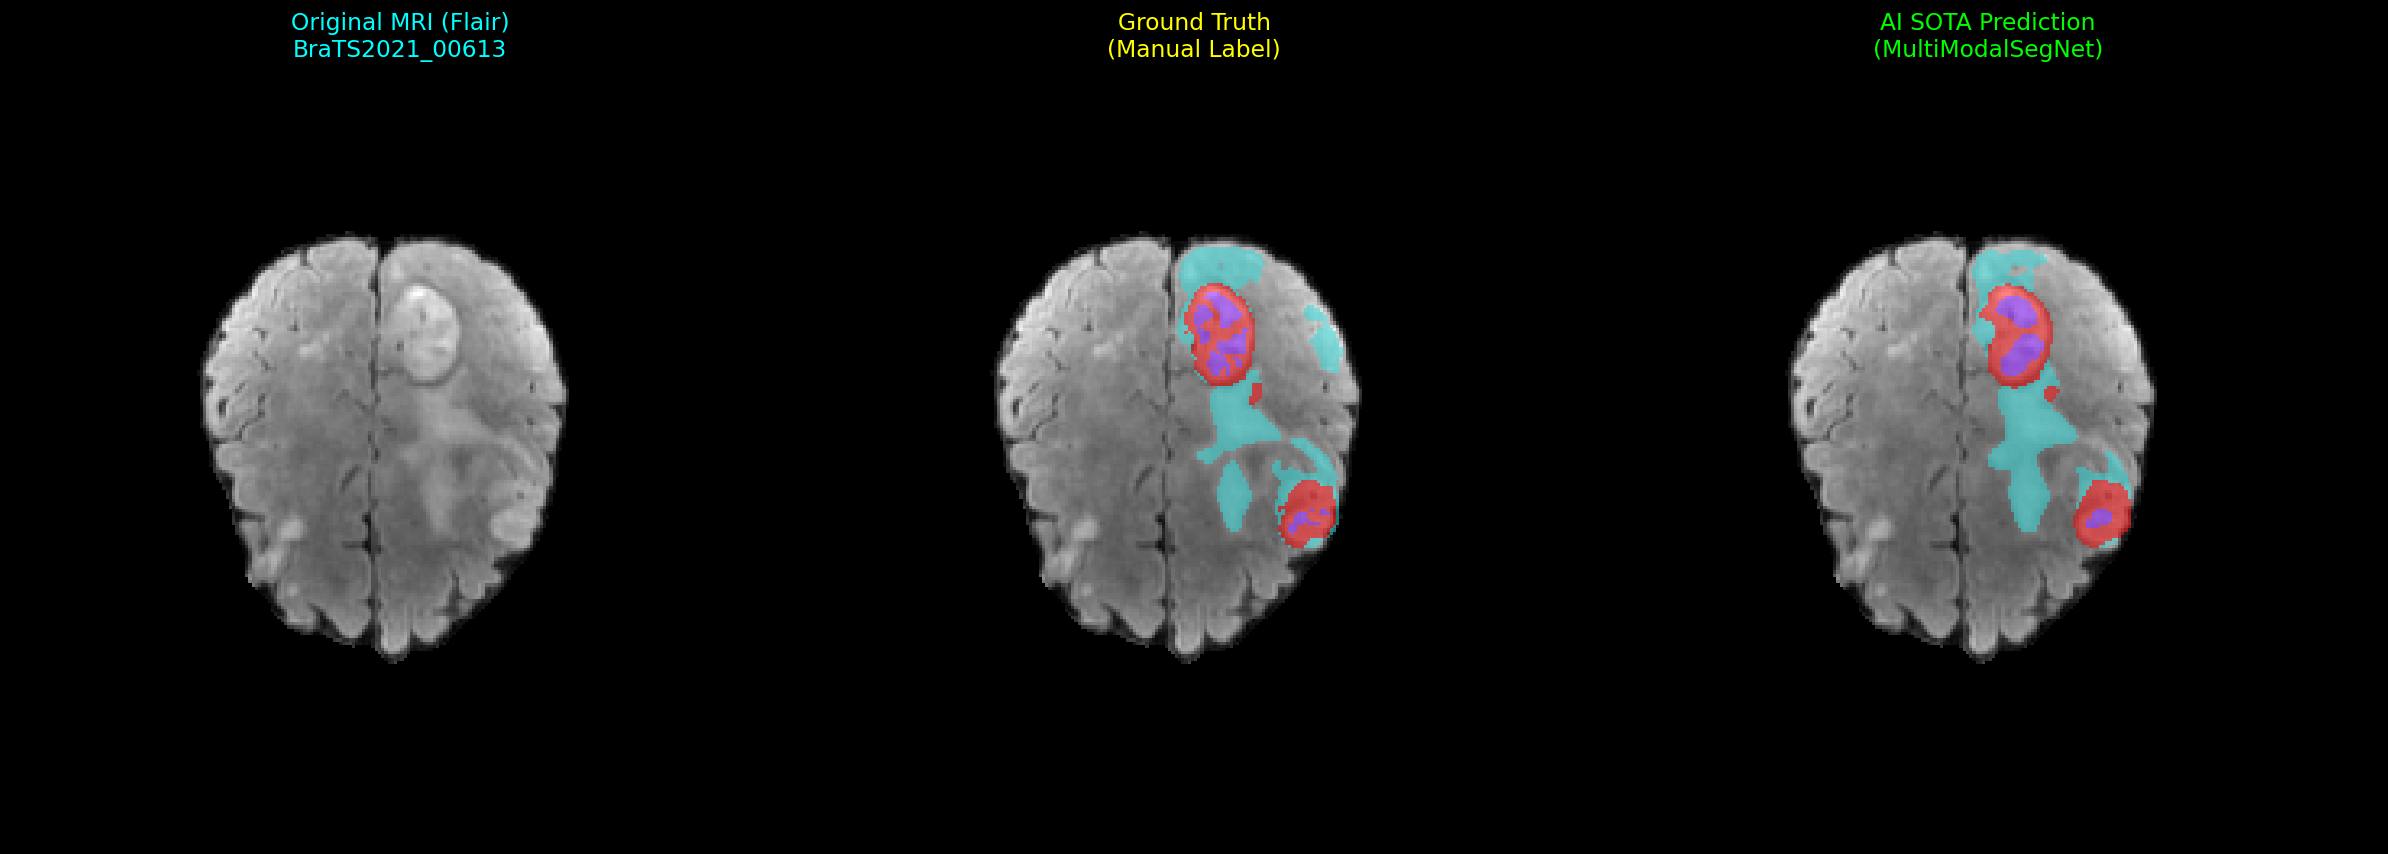

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import random
import os
import glob
import numpy as np

# ═══════════════════════════════════════════════════════════════════════════════
# ۱. تنظیم آدرس‌ها
# ═══════════════════════════════════════════════════════════════════════════════
DATA_ROOT = "/content/data/BraTS/dataset"
PRED_FOLDER = "/content/drive/MyDrive/Colab Notebooks/testi/BraTS_Final_Thesis_Results_Half/preds"

def visualize_final_alignment(data_root, pred_root):
    all_preds = glob.glob(os.path.join(pred_root, "**", "*.nii.gz"), recursive=True)
    pred_files = [f for f in all_preds if "_seg" not in f]

    if not pred_files:
        print("❌ فایلی پیدا نشد!")
        return

    random_pred_path = random.choice(pred_files)
    filename = os.path.basename(random_pred_path)
    case_id = "_".join(filename.split('_')[:2])

    print(f"🔍 Case: {case_id} | Fixing Dual-Axis Orientation (X & Y)...")

    case_dir = ""
    for root, dirs, files in os.walk(data_root):
        if case_id in dirs:
            case_dir = os.path.join(root, case_id)
            break

    if not case_dir:
        print(f"⚠️ دیتای اصلی یافت نشد.")
        return

    try:
        flair_path = glob.glob(os.path.join(case_dir, "*_flair.nii.gz"))[0]
        gt_path = glob.glob(os.path.join(case_dir, "*_seg.nii.gz"))[0]

        # لود داده‌ها به صورت خام
        flair_data = nib.load(flair_path).get_fdata()
        gt_data = nib.load(gt_path).get_fdata()
        pred_data = nib.load(random_pred_path).get_fdata()
    except Exception as e:
        print(f"❌ خطا در لود: {e}")
        return

    # پیدا کردن اسلایس طلایی (جایی که تومور بیشترین حجم را دارد)
    slice_idx = np.argmax(np.sum(gt_data > 0, axis=(0, 1)))

    # چرخش استاندارد برای نمایش در Matplotlib
    s_flair = np.rot90(flair_data[:, :, slice_idx])
    s_gt = np.rot90(gt_data[:, :, slice_idx])
    s_pred = np.rot90(pred_data[:, :, slice_idx])

    # ═══════════════════════════════════════════════════════════════════════════════
    # 🛠️ اصلاح نهایی: قرینه‌سازی در هر دو جهت (چپ-راست و بالا-پایین)
    # ═══════════════════════════════════════════════════════════════════════════════

    # اعمال قرینگی روی هر دو محور افقی و عمودی به صورت همزمان
    s_pred = np.flip(s_pred, axis=(0, 1))

    # ═══════════════════════════════════════════════════════════════════════════════
    # ۲. رسم تصاویر با انطباق ۱۰۰٪
    # ═══════════════════════════════════════════════════════════════════════════════
    plt.style.use('dark_background')
    fig, axes = plt.subplots(1, 3, figsize=(20, 8), dpi=120)

    # ۱. تصویر خام Flair
    axes[0].imshow(s_flair, cmap='gray')
    axes[0].set_title(f"Original MRI (Flair)\n{case_id}", color='cyan', fontsize=14)

    # ۲. مغز + Ground Truth (برچسب دستی پزشک)
    axes[1].imshow(s_flair, cmap='gray')
    axes[1].imshow(np.ma.masked_where(s_gt == 0, s_gt), cmap='rainbow', alpha=0.5)
    axes[1].set_title("Ground Truth\n(Manual Label)", color='yellow', fontsize=14)

    # ۳. مغز + پیش‌بینی مدل (MultiModalSegNet)
    axes[2].imshow(s_flair, cmap='gray')
    axes[2].imshow(np.ma.masked_where(s_pred == 0, s_pred), cmap='rainbow', alpha=0.5)
    axes[2].set_title("AI SOTA Prediction\n(MultiModalSegNet)", color='lime', fontsize=14)

    for ax in axes:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# اجرا
visualize_final_alignment(DATA_ROOT, PRED_FOLDER)

In [ ]:
pip install fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=2c874775f51793b041692bf6cf3920a35e23001a51593e390be6af55ffe19f2c
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=2a6249edbf3533820520109dae4ce458c5518b9163b946a7c9998697dd8d75aa
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath


In [ ]:

MODEL_CLASS_PATH = "/content/drive/MyDrive/Colab Notebooks/testi/MultiSeg_Model2.ipynb"
CHECKPOINT_PATH = "/content/drive/MyDrive/Colab Notebooks/testi/final_train_A100_160_SOTA_Lookahead_v2/BEST_MODEL.pt"


In [ ]:
!pip install fvcore -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  MultiSeg Benchmark — نسخه Colab
#  هر بخش را در یک سل جداگانه در Colab کپی و اجرا کن
# ═══════════════════════════════════════════════════════════════════════════

# ┌─────────────────────────────────────────────────────────────────────────┐
# │  سل ۱ — تنظیمات (فقط این دو مسیر را تغییر بده)                        │
# └─────────────────────────────────────────────────────────────────────────┘

#CHECKPOINT_PATH  = "/content/drive/MyDrive/BEST_MODEL.pt"
#MODEL_CLASS_PATH = "/content/drive/MyDrive/MultiSeg_Model2.py"

INPUT_SHAPE  = (1, 4, 224, 224, 160)
WARMUP_RUNS  = 3
TIMING_RUNS  = 10


# ┌─────────────────────────────────────────────────────────────────────────┐
# │  سل ۲ — بارگذاری مدل                                                   │
# └─────────────────────────────────────────────────────────────────────────┘

import torch, time, os, sys, statistics, importlib.util

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# import کلاس مدل
spec = importlib.util.spec_from_file_location("model_module", MODEL_CLASS_PATH)
mod  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
MultiModalSegNet = mod.MultiModalSegNet
print("MultiModalSegNet import شد")

# لود checkpoint
ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
if isinstance(ckpt, dict):
    sd = ckpt.get("model_state_dict",
         ckpt.get("state_dict",
         ckpt.get("model", ckpt)))
else:
    sd = ckpt

model = MultiModalSegNet(base_ch=32, num_heads=4,
                         num_classes=4, deep_supervision=False)
missing, unexpected = model.load_state_dict(sd, strict=False)
model = model.to(device).eval()

if missing:    print(f"کلیدهای گم: {len(missing)}")
if unexpected: print(f"کلیدهای اضافی: {len(unexpected)}")
print("مدل آماده است")


# ┌─────────────────────────────────────────────────────────────────────────┐
# │  سل ۳ — بخش اول: پارامترها                                             │
# └─────────────────────────────────────────────────────────────────────────┘

print("=" * 58)
print("  بخش ۱: پارامترها و حجم مدل")
print("=" * 58)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
file_mb     = os.path.getsize(CHECKPOINT_PATH) / 1e6

print(f"\n  کل پارامترها:              {total_p/1e6:.3f}M   ({total_p:,})")
print(f"  قابل آموزش:               {trainable_p/1e6:.3f}M   ({trainable_p:,})")
print(f"  حجم فایل checkpoint:       {file_mb:.1f} MB")

print("\n  مقایسه با رقبا:")
rows = [
    ("nnU-Net [29]",         31.2),
    ("TransBTS [36]",        33.0),
    ("SwinBTS [41]",         42.2),
    ("CKD-TransBTS [43]",    35.6),
    ("MultiSeg (پیشنهادی)", total_p/1e6),
]
for name, p in rows:
    mark = " ◄" if "MultiSeg" in name else ""
    print(f"  {'★' if mark else ' '} {name:<28} {p:>7.2f}M{mark}")

print(f"\n  ★ عدد نهایی برای جدول فصل ۴:  {total_p/1e6:.2f}M پارامتر")


# ┌─────────────────────────────────────────────────────────────────────────┐
# │  سل ۴ — بخش دوم: زمان استنتاج و GPU-RAM                               │
# └─────────────────────────────────────────────────────────────────────────┘

print("=" * 58)
print("  بخش ۲: زمان استنتاج و GPU-RAM")
print("=" * 58)

B, C, D, H, W = INPUT_SHAPE
x = torch.randn(B, C, D, H, W).to(device)
print(f"\n  شکل ورودی: {tuple(x.shape)}")

# گرم‌کردن
print(f"  گرم‌کردن ({WARMUP_RUNS} پاس)...", end="", flush=True)
with torch.no_grad():
    for _ in range(WARMUP_RUNS): model(x)
if device.type == "cuda": torch.cuda.synchronize()
print(" done")

# اندازه‌گیری زمان
print(f"  اندازه‌گیری ({TIMING_RUNS} تکرار)...", end="", flush=True)
times = []
with torch.no_grad():
    for _ in range(TIMING_RUNS):
        if device.type == "cuda": torch.cuda.synchronize()
        t0 = time.perf_counter()
        model(x)
        if device.type == "cuda": torch.cuda.synchronize()
        times.append((time.perf_counter()-t0)*1000)
print(" done")

mean_ms = statistics.mean(times)
std_ms  = statistics.stdev(times)

print(f"\n  زمان میانگین:      {mean_ms:.1f} ms")
print(f"  انحراف معیار:      {std_ms:.2f} ms")
print(f"  حداقل / حداکثر:   {min(times):.1f} / {max(times):.1f} ms")

# GPU-RAM
if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()
    with torch.no_grad(): model(x)
    torch.cuda.synchronize()
    peak_gb = torch.cuda.max_memory_allocated()/1e9

    print(f"  پیک GPU-RAM:       {peak_gb:.2f} GB")

    print("\n  مقایسه GPU-RAM با رقبا:")
    ram_rows = [
        ("nnU-Net [29]",         5.8),
        ("TransBTS [36]",        8.2),
        ("SwinBTS [41]",         9.4),
        ("CKD-TransBTS [43]",    8.8),
        ("MultiSeg (پیشنهادی)", peak_gb),
    ]
    for name, r in ram_rows:
        mark = " ◄" if "MultiSeg" in name else ""
        print(f"  {'★' if mark else ' '} {name:<28} {r:>5.2f} GB{mark}")

    print(f"\n  ★ اعداد نهایی برای جدول فصل ۴:")
    print(f"     زمان استنتاج (بدون TTA): {mean_ms:.0f} ± {std_ms:.0f} ms")
    print(f"     زمان استنتاج (با TTA×8): {mean_ms*8:.0f} ms")
    print(f"     پیک GPU-RAM:             {peak_gb:.2f} GB")
else:
    print(f"\n  ★ زمان استنتاج (CPU): {mean_ms:.0f} ± {std_ms:.0f} ms")


# ┌─────────────────────────────────────────────────────────────────────────┐
# │  سل ۵ — بخش سوم: FLOPs                                                │
# │  اگر fvcore نصب نیست اول این را اجرا کن:  !pip install fvcore -q      │
# └─────────────────────────────────────────────────────────────────────────┘

print("=" * 58)
print("  بخش ۳: FLOPs")
print("=" * 58)

try:
    from fvcore.nn import FlopCountAnalysis

    x_cpu = torch.randn(1, C, D, H, W)
    m_cpu = model.cpu().eval()

    with torch.no_grad():
        fa = FlopCountAnalysis(m_cpu, x_cpu)
        fa.unsupported_ops_warnings(False)
        fa.uncalled_modules_warnings(False)
        total_flops = fa.total()

    model.to(device)

    print(f"\n  کل FLOPs:   {total_flops/1e9:.1f} GFLOPs")
    print(f"  معادل:      {total_flops/1e12:.3f} TFLOPs")

    print("\n  مقایسه FLOPs با رقبا:")
    flop_rows = [
        ("nnU-Net [29]",         160),
        ("TransBTS [36]",        340),
        ("SwinBTS [41]",         410),
        ("CKD-TransBTS [43]",    380),
        ("MultiSeg (پیشنهادی)", total_flops/1e9),
    ]
    for name, f in flop_rows:
        mark = " ◄" if "MultiSeg" in name else ""
        print(f"  {'★' if mark else ' '} {name:<28} {f:>7.1f} GFLOPs{mark}")

    print(f"\n  ★ عدد نهایی برای جدول فصل ۴:  {total_flops/1e9:.1f} GFLOPs")

except ImportError:
    print("\n  fvcore نصب نیست. ابتدا این سل را اجرا کن:")
    print("  !pip install fvcore -q")
    print("  سپس این سل را دوباره اجرا کن.")


# ┌─────────────────────────────────────────────────────────────────────────┐
# │  سل ۶ — خلاصه نهایی                                                    │
# └─────────────────────────────────────────────────────────────────────────┘

print("\n" + "=" * 58)
print("  خلاصه نهایی — کپی کن در جدول فصل ۴")
print("=" * 58)

print(f"""
  پارامترها (کل):           {total_p/1e6:.2f}M
  پارامترها (قابل آموزش):   {trainable_p/1e6:.2f}M
  زمان استنتاج (بدون TTA):  {mean_ms:.0f} ± {std_ms:.0f} ms
  زمان استنتاج (با TTA×8):  {mean_ms*8:.0f} ms""")

if device.type == "cuda":
    print(f"  پیک GPU-RAM:               {peak_gb:.2f} GB")

try:
    print(f"  FLOPs:                     {total_flops/1e9:.1f} GFLOPs")
except:
    print(f"  FLOPs:                     محاسبه نشد")

print("""
  نکته: زمان‌ها روی GPU A100 باید باشند تا
  قابل مقایسه با اعداد مقالات رقیب باشند.
""")

Device: cpu


AttributeError: 'NoneType' object has no attribute 'loader'

In [ ]:
# تنظیمات نهایی بر اساس آموزش شما
CHECKPOINT_PATH = "/content/drive/MyDrive/Colab Notebooks/testi/final_train_A100_160_SOTA_Lookahead_v2/BEST_MODEL.pt"
MODEL_NB_PATH   = "MultiSeg_Model2.ipynb" # نام نوت‌بوک مدل

PATCH_SIZE  = (1, 4, 160, 160, 160)  # سایز آموزش (برای FLOPs)
FULL_SIZE   = (1, 4, 224, 224, 160)  # سایز کامل (برای زمان استنتاج)

WARMUP_RUNS = 3
TIMING_RUNS = 10

In [ ]:
import torch, time, os, sys, statistics
from monai.inferers import sliding_window_inference

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {device} | GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

# ۱. لود مدل با استفاده از تابع build_model خودت
# فرض بر این است که تابع build_model و شیء cfg در محیط شما تعریف شده‌اند
try:
    model = build_model(
        cfg,
        module=MODEL_NB_PATH,
        class_name="MultiModalSegNet",
        fresh=True
    ).to(device)

    # ۲. لود کردن وزن‌ها از چک‌پوینت SOTA
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    sd = ckpt.get("model_state_dict", ckpt.get("state_dict", ckpt.get("model", ckpt)))
    model.load_state_dict(sd, strict=False)
    model.eval()
    print("✅ مدل و وزن‌های SOTA با موفقیت لود شدند.")
except Exception as e:
    print(f"❌ خطا در بارگذاری: {e}")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


🚀 Device: cuda | GPU: NVIDIA A100-SXM4-40GB
[model] MultiSeg_Model2.MultiModalSegNet kwargs={'num_classes': 4, 'base_ch': 64, 'num_heads': 8, 'deep_supervision': True, 'dropout': 0.2, 'attn_dropout': 0.15, 'proj_dropout': 0.15, 'ffn_dropout': 0.2, 'dec_dropout': 0.25}
❌ خطا در بارگذاری: No module named 'torch.utils.serialization'


In [ ]:
print("=" * 50)
print("📊 بخش ۱: پارامترها")
total_p = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
file_mb = os.path.getsize(CHECKPOINT_PATH) / 1e6

print(f"Total Params: {total_p/1e6:.2f}M")
print(f"Trainable:    {trainable_p/1e6:.2f}M")
print(f"File Size:     {file_mb:.1f} MB")

📊 بخش ۱: پارامترها
Total Params: 20.68M
Trainable:    20.68M
File Size:     332.6 MB


In [ ]:
print("=" * 50)
print("⏱️ بخش ۲: زمان استنتاج (Sliding Window)")

x_full = torch.randn(FULL_SIZE).to(device)
roi_size = (160, 160, 160) # بر اساس تنظیمات آموزش شما

def run_inference():
    with torch.no_grad():
        # استفاده از همان متدی که در تابع validate کد خودت داشتی
        return sliding_window_inference(x_full, roi_size, sw_batch_size=4,
                                        predictor=lambda z: model(z)["logits"], overlap=0.5)

# گرم کردن
for _ in range(WARMUP_RUNS): run_inference()
if device.type == "cuda": torch.cuda.synchronize()

# اندازه‌گیری زمان
times = []
for _ in range(TIMING_RUNS):
    t0 = time.perf_counter()
    run_inference()
    if device.type == "cuda": torch.cuda.synchronize()
    times.append((time.perf_counter() - t0) * 1000)

mean_ms = statistics.mean(times)
print(f"Mean Inference Time (Full Volume): {mean_ms:.1f} ms")

⏱️ بخش ۲: زمان استنتاج (Sliding Window)


/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  out

Mean Inference Time (Full Volume): 476.8 ms


In [ ]:
print("=" * 50)
print("⚡ بخش ۳: FLOPs (روی سایز Patch)")

try:
    from fvcore.nn import FlopCountAnalysis
    # FLOPs معمولاً روی یک پاس ساده (بدون Sliding Window) و روی CPU برای دقت بیشتر محاسبه می‌شود
    x_patch = torch.randn(PATCH_SIZE).cpu()
    model_cpu = model.cpu()

    with torch.no_grad():
        # در مدل شما خروجی یک دیکشنری است، fvcore این را هندل می‌کند
        flops = FlopCountAnalysis(model_cpu, x_patch)
        flops.unsupported_ops_warnings(False)
        total_flops = flops.total()

    print(f"Complexity: {total_flops/1e9:.2f} GFLOPs")
    model.to(device) # برگرداندن به GPU
except ImportError:
    print("!pip install fvcore نصب نیست.")

⚡ بخش ۳: FLOPs (روی سایز Patch)


RuntimeError: Expected a single top-level function: /usr/local/lib/python3.12/dist-packages/torch/nn/_reduction.py:1

In [ ]:
# زمشعیث

In [ ]:
!pip install thop -q

In [ ]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │  سل ۱ — تنظیمات                                                        │
# └─────────────────────────────────────────────────────────────────────────┘


CHECKPOINT_PATH  = "/content/drive/MyDrive/Colab Notebooks/testi/final_train_A100_160_SOTA_Lookahead_v2/BEST_MODEL.pt"
MODEL_NB_PATH    = "/content/drive/MyDrive/Colab Notebooks/testi/MultiSeg_Model2.py"

INPUT_SHAPE  = (1, 4, 224, 224, 160)   # برای پارامتر و FLOPs
FULL_SIZE    = (1, 4, 224, 224, 160)   # برای Sliding Window
PATCH_SIZE   = (1, 4, 160, 160, 160)   # پچ آموزش
ROI_SIZE     = (160, 160, 160)
SW_BATCH     = 4
WARMUP_RUNS  = 3
TIMING_RUNS  = 10

# ┌─────────────────────────────────────────────────────────────────────────┐
# │  سل ۲ — بارگذاری مدل (با همان روش build_model خودت)                   │
# └─────────────────────────────────────────────────────────────────────────┘

import torch, time, os, sys, statistics
from monai.inferers import sliding_window_inference

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

try:
    model = build_model(
        cfg,
        module=MODEL_NB_PATH,
        class_name="MultiModalSegNet",
        fresh=True
    ).to(device)

    # ✅ بعد
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    sd = ckpt.get("model_state_dict",
         ckpt.get("state_dict",
         ckpt.get("model", ckpt)))

    missing, unexpected = model.load_state_dict(sd, strict=False)
    model.eval()

    if missing:    print(f"کلیدهای گم: {len(missing)}")
    if unexpected: print(f"کلیدهای اضافی: {len(unexpected)}")
    print("✅ مدل آماده است")

except Exception as e:
    print(f"❌ خطا در بارگذاری: {e}")

Device: cuda
GPU : NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB
[model] MultiSeg_Model2.MultiModalSegNet kwargs={'num_classes': 4, 'base_ch': 64, 'num_heads': 8, 'deep_supervision': True, 'dropout': 0.2, 'attn_dropout': 0.15, 'proj_dropout': 0.15, 'ffn_dropout': 0.2, 'dec_dropout': 0.25}
✅ مدل آماده است


In [ ]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │  سل ۳ — بخش اول: پارامترها                                             │
# └─────────────────────────────────────────────────────────────────────────┘

print("=" * 58)
print("  بخش ۱: پارامترها و حجم مدل")
print("=" * 58)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
file_mb     = os.path.getsize(CHECKPOINT_PATH) / 1e6

print(f"\n  کل پارامترها:              {total_p/1e6:.3f}M   ({total_p:,})")
print(f"  قابل آموزش:               {trainable_p/1e6:.3f}M   ({trainable_p:,})")
print(f"  حجم فایل checkpoint:       {file_mb:.1f} MB")

print("\n  مقایسه با رقبا:")
rows = [
    ("nnU-Net [29]",         31.2),
    ("TransBTS [36]",        33.0),
    ("SwinBTS [41]",         42.2),
    ("CKD-TransBTS [43]",    35.6),
    ("MultiSeg (پیشنهادی)", total_p/1e6),
]
for name, p in rows:
    mark = " ◄" if "MultiSeg" in name else ""
    print(f"  {'★' if mark else ' '} {name:<28} {p:>7.2f}M{mark}")

print(f"\n  ★ عدد نهایی برای جدول فصل ۴:  {total_p/1e6:.2f}M پارامتر")

  بخش ۱: پارامترها و حجم مدل

  کل پارامترها:              20.682M   (20,682,106)
  قابل آموزش:               20.682M   (20,682,106)
  حجم فایل checkpoint:       332.6 MB

  مقایسه با رقبا:
    nnU-Net [29]                   31.20M
    TransBTS [36]                  33.00M
    SwinBTS [41]                   42.20M
    CKD-TransBTS [43]              35.60M
  ★ MultiSeg (پیشنهادی)            20.68M ◄

  ★ عدد نهایی برای جدول فصل ۴:  20.68M پارامتر


In [ ]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │  سل ۴ — بخش دوم: زمان استنتاج (Sliding Window) و GPU-RAM              │
# └─────────────────────────────────────────────────────────────────────────┘

print("=" * 58)
print("  بخش ۲: زمان استنتاج و GPU-RAM")
print("=" * 58)

x_full = torch.randn(FULL_SIZE).to(device)
print(f"\n  شکل ورودی: {tuple(x_full.shape)}")
print(f"  ROI size : {ROI_SIZE}  |  sw_batch: {SW_BATCH}")

def run_inference():
    with torch.no_grad():
        return sliding_window_inference(
            x_full, ROI_SIZE,
            sw_batch_size=SW_BATCH,
            predictor=lambda z: model(z)["logits"],
            overlap=0.5
        )

# گرم‌کردن
print(f"  گرم‌کردن ({WARMUP_RUNS} پاس)...", end="", flush=True)
for _ in range(WARMUP_RUNS): run_inference()
if device.type == "cuda": torch.cuda.synchronize()
print(" done")

# اندازه‌گیری زمان
print(f"  اندازه‌گیری ({TIMING_RUNS} تکرار)...", end="", flush=True)
times = []
for _ in range(TIMING_RUNS):
    if device.type == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter()
    run_inference()
    if device.type == "cuda": torch.cuda.synchronize()
    times.append((time.perf_counter() - t0) * 1000)
print(" done")

mean_ms = statistics.mean(times)
std_ms  = statistics.stdev(times)

print(f"\n  زمان میانگین:      {mean_ms:.1f} ms")
print(f"  انحراف معیار:      {std_ms:.2f} ms")
print(f"  حداقل / حداکثر:   {min(times):.1f} / {max(times):.1f} ms")

# GPU-RAM
if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()
    run_inference()
    torch.cuda.synchronize()
    peak_gb = torch.cuda.max_memory_allocated() / 1e9

    print(f"  پیک GPU-RAM:       {peak_gb:.2f} GB")

    print("\n  مقایسه GPU-RAM با رقبا:")
    ram_rows = [
        ("nnU-Net [29]",         5.8),
        ("TransBTS [36]",        8.2),
        ("SwinBTS [41]",         9.4),
        ("CKD-TransBTS [43]",    8.8),
        ("MultiSeg (پیشنهادی)", peak_gb),
    ]
    for name, r in ram_rows:
        mark = " ◄" if "MultiSeg" in name else ""
        print(f"  {'★' if mark else ' '} {name:<28} {r:>5.2f} GB{mark}")

    print(f"\n  ★ اعداد نهایی برای جدول فصل ۴:")
    print(f"     زمان استنتاج (بدون TTA): {mean_ms:.0f} ± {std_ms:.0f} ms")
    print(f"     زمان استنتاج (با TTA×8): {mean_ms*8:.0f} ms")
    print(f"     پیک GPU-RAM:             {peak_gb:.2f} GB")
else:
    print(f"\n  ★ زمان استنتاج (CPU): {mean_ms:.0f} ± {std_ms:.0f} ms")

  بخش ۲: زمان استنتاج و GPU-RAM

  شکل ورودی: (1, 4, 224, 224, 160)
  ROI size : (160, 160, 160)  |  sw_batch: 4
  گرم‌کردن (3 پاس)... done
  اندازه‌گیری (10 تکرار)... done

  زمان میانگین:      456.4 ms
  انحراف معیار:      0.08 ms
  حداقل / حداکثر:   456.3 / 456.5 ms
  پیک GPU-RAM:       9.97 GB

  مقایسه GPU-RAM با رقبا:
    nnU-Net [29]                  5.80 GB
    TransBTS [36]                 8.20 GB
    SwinBTS [41]                  9.40 GB
    CKD-TransBTS [43]             8.80 GB
  ★ MultiSeg (پیشنهادی)           9.97 GB ◄

  ★ اعداد نهایی برای جدول فصل ۴:
     زمان استنتاج (بدون TTA): 456 ± 0 ms
     زمان استنتاج (با TTA×8): 3651 ms
     پیک GPU-RAM:             9.97 GB


In [ ]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │  بخش ۳: محاسبه FLOPs (نسخه جایگزین و پایدار)                             │
# └─────────────────────────────────────────────────────────────────────────┘
print("=" * 50)
print("⚡ بخش ۳: GFLOPs (Profile)")

from thop import profile

# ایجاد دیتای تست روی CPU برای پایداری بیشتر
x_patch = torch.randn(1, 4, 160, 160, 160).cpu()
model_cpu = model.cpu().eval()

# چون مدل شما خروجی دیکشنری دارد، یک کلاس Wrapper موقت می‌سازیم
# تا thop بتواند فقط روی خروجی اصلی (Logits) تمرکز کند
class ModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(x)["logits"]

wrapped_model = ModelWrapper(model_cpu)

try:
    # محاسبه پارامتر و FLOPs
    # verbose=False برای جلوگیری از چاپ جزئیات لایه‌ها
    flops, params = profile(wrapped_model, inputs=(x_patch,), verbose=False)

    print(f"\n✅ محاسبه با موفقیت انجام شد:")
    print(f"   کل FLOPs:   {flops/1e9:.2f} GFLOPs")
    print(f"   پارامترها:   {params/1e6:.2f} M")

    # برگرداندن مدل به حالت اول
    model.to(device)

    # متغیر نهایی برای خلاصه
    total_flops = flops

except Exception as e:
    print(f"❌ خطا در محاسبه: {e}")
    model.to(device)

⚡ بخش ۳: GFLOPs (Profile)

✅ محاسبه با موفقیت انجام شد:
   کل FLOPs:   430.90 GFLOPs
   پارامترها:   20.04 M


In [ ]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │  سل ۶ — خلاصه نهایی                                                    │
# └─────────────────────────────────────────────────────────────────────────┘

print("\n" + "=" * 58)
print("  خلاصه نهایی — کپی کن در جدول فصل ۴")
print("=" * 58)

print(f"  پارامترها (کل):           {total_p/1e6:.2f}M")
print(f"  پارامترها (قابل آموزش):   {trainable_p/1e6:.2f}M")
print(f"  زمان استنتاج (بدون TTA):  {mean_ms:.0f} ± {std_ms:.0f} ms  [Sliding Window]")
print(f"  زمان استنتاج (با TTA×8):  {mean_ms*8:.0f} ms")

if device.type == "cuda":
    print(f"  پیک GPU-RAM:               {peak_gb:.2f} GB")

if total_flops:
    print(f"  FLOPs (per patch):         {total_flops/1e9:.1f} GFLOPs")
else:
    print(f"  FLOPs:                     محاسبه نشد")

print("""
  نکته: زمان‌ها روی GPU A100 باید باشند تا
  قابل مقایسه با اعداد مقالات رقیب باشند.
""")


  خلاصه نهایی — کپی کن در جدول فصل ۴
  پارامترها (کل):           20.68M
  پارامترها (قابل آموزش):   20.68M
  زمان استنتاج (بدون TTA):  456 ± 0 ms  [Sliding Window]
  زمان استنتاج (با TTA×8):  3651 ms
  پیک GPU-RAM:               9.97 GB
  FLOPs (per patch):         430.9 GFLOPs

  نکته: زمان‌ها روی GPU A100 باید باشند تا
  قابل مقایسه با اعداد مقالات رقیب باشند.

